In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

# Data Importing

In [64]:
data_loc = ".\\datasets\\RAVDESS\\"

emotional_map = {"01":"neutral",
                 "02":"calm",
                 "03":"happy",
                 "04":"sad",
                 "05":"angry",
                 "06":"fearful",
                 "07":"disgust",
                 "08":"surprised"}

In [65]:
data = []

for actor_folder in os.listdir(data_loc):
    actor_path = os.path.join(data_loc,actor_folder)

    if not os.path.isdir(actor_path):
        continue
    
    actor_id = actor_folder.split("_")[-1]

    for file in os.listdir(actor_path):
        if not file.endswith(".mp4"):
            continue

        parts = file.split("-")
        emotion_code = parts[2]

        data.append({
            "video_path": os.path.join(actor_path,file),
            "emotion": emotional_map[emotion_code],
            "actor_id": int(actor_id)
        })
        
df = pd.DataFrame(data)

In [66]:
print(df.head())
print(df['emotion'].value_counts())

                                          video_path  emotion  actor_id
0  .\datasets\RAVDESS\Actor_01\01-01-01-01-01-01-...  neutral         1
1  .\datasets\RAVDESS\Actor_01\01-01-01-01-01-02-...  neutral         1
2  .\datasets\RAVDESS\Actor_01\01-01-01-01-02-01-...  neutral         1
3  .\datasets\RAVDESS\Actor_01\01-01-01-01-02-02-...  neutral         1
4  .\datasets\RAVDESS\Actor_01\01-01-02-01-01-01-...     calm         1
emotion
calm         384
happy        384
sad          384
fearful      384
surprised    384
angry        383
disgust      383
neutral      192
Name: count, dtype: int64


In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['emotion_label'] = le.fit_transform(df['emotion'])

df.head()

,video_path,emotion,actor_id,emotion_label
0,.\datasets\RAVDESS\Actor_01\01-01-01-01-01-01-...,neutral,1,5
1,.\datasets\RAVDESS\Actor_01\01-01-01-01-01-02-...,neutral,1,5
2,.\datasets\RAVDESS\Actor_01\01-01-01-01-02-01-...,neutral,1,5
3,.\datasets\RAVDESS\Actor_01\01-01-01-01-02-02-...,neutral,1,5
4,.\datasets\RAVDESS\Actor_01\01-01-02-01-01-01-...,calm,1,1


### Extract video info

In [68]:
def get_video_data(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return (-1,-1,-1)

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = 0
    
    
    if fps == 0:
        duration = 0
    else:
        duration = frames/fps

    cap.release()
    return (frames, fps, duration, w, h)

In [69]:
video_tuples = df['video_path'].apply(get_video_data)

In [70]:
df = pd.concat((df,pd.DataFrame(video_tuples.tolist(),columns=['num_frames','fps','duration','width','height'])),axis=1)
df.head()

,video_path,emotion,actor_id,emotion_label,num_frames,fps,duration,width,height
0,.\datasets\RAVDESS\Actor_01\01-01-01-01-01-01-...,neutral,1,5,99,29,3.413793,1280,720
1,.\datasets\RAVDESS\Actor_01\01-01-01-01-01-02-...,neutral,1,5,100,29,3.448276,1280,720
2,.\datasets\RAVDESS\Actor_01\01-01-01-01-02-01-...,neutral,1,5,98,29,3.379310,1280,720
3,.\datasets\RAVDESS\Actor_01\01-01-01-01-02-02-...,neutral,1,5,95,29,3.275862,1280,720
4,.\datasets\RAVDESS\Actor_01\01-01-02-01-01-01-...,calm,1,1,106,29,3.655172,1280,720


### Extract frames

In [71]:
def extract_frames(video_path, max_frames=40):
    frames = []
    cap = cv2.VideoCapture(video_path)
    
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (854, 480))
        frames.append(frame)
    
    cap.release()
    
    # Pad if needed
    while len(frames) < max_frames:
        frames.append(np.zeros((854,480,3)))
    
    return np.array(frames)

# EDA
Some eda graphs

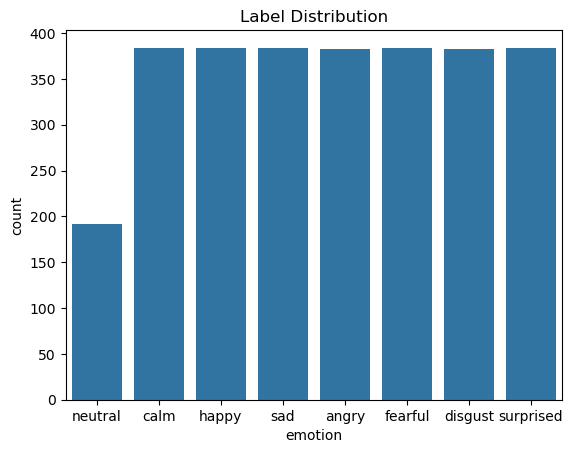

In [24]:
sns.countplot(x=df['emotion'])
plt.title('Label Distribution')
plt.show()

### Label Distribution Analysis
This shows that there is an imbalance for the neutral label. This could cause an issue later on, so we will need to upscale the dataset or weight the classes during training.

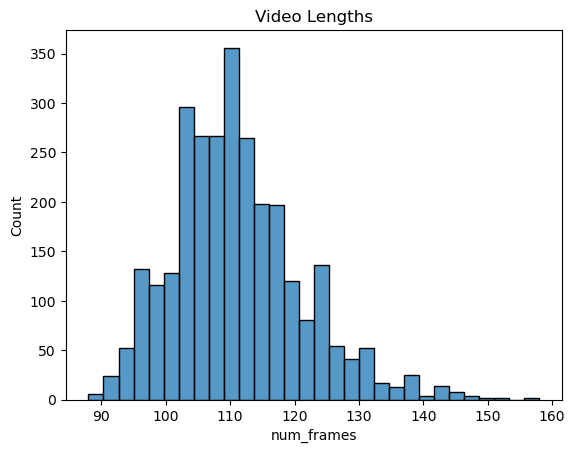

In [62]:
sns.histplot(df['num_frames'],bins=30)
plt.title("Video Lengths")
plt.show()

### Video Lengths Analysis
Althought there is some spread of the duration of the videos, the difference between the shortest and longest shouldn't be too much of an issue.

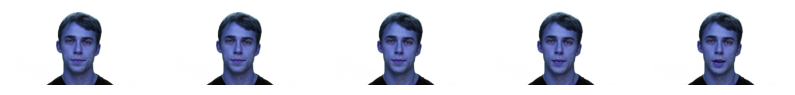

In [76]:
frames = extract_frames(df['video_path'][500])

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(frames[i])
    plt.axis('off')
plt.show()

### Frame Analysis
This is just a quick test to make sure everything is working so far, and we don't have any blur, noise, or other issues on the images.

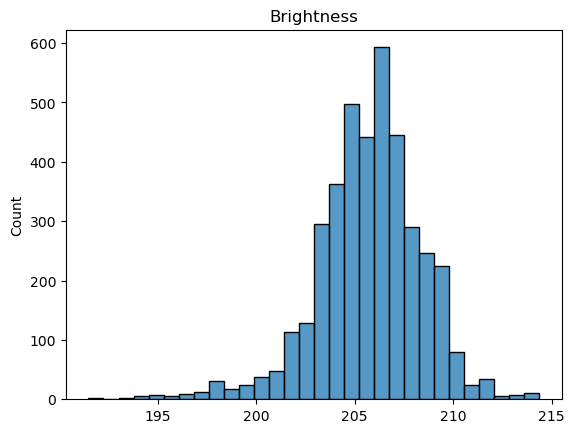

In [77]:
brightness = []

for vid in df['video_path'][:100]:
    frames = extract_frames(vid)
    brightness.extend(np.mean(frames,axis=(1,2,3)))

sns.histplot(brightness,bins=30)
plt.title("Brightness")
plt.show()

### Brightness Analysis
This distribution shows there is no need to be concerned about the brightness difference for the videos, as they are all around 200-210 average brightness.

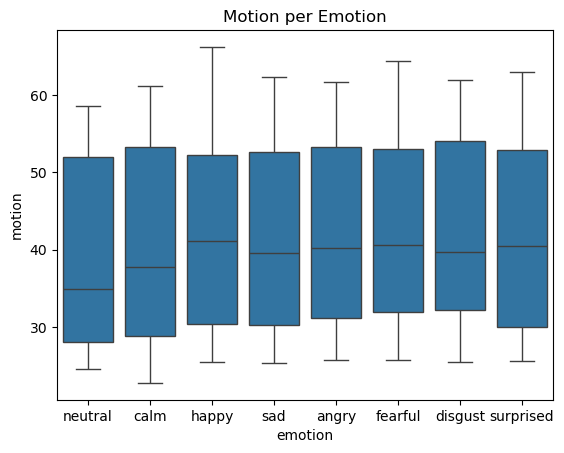

In [78]:
def frame_diff(frames):
    diffs = []
    for i in range(1, len(frames)):
        diffs.append(np.mean(np.abs(frames[i] - frames[i-1])))
    return np.mean(diffs)

df['motion'] = df['video_path'].apply(lambda x: frame_diff(extract_frames(x)))

sns.boxplot(x='emotion', y='motion', data=df)
plt.title("Motion per Emotion")
plt.show()

### Frame Difference Analysis
This is another good sign, as there doesn't appear to be any outliers for the motion of the frames. This means one less step for our data prep.

In [85]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [86]:
def detect_faces_in_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )
    return len(faces) > 0

In [87]:
def faces_detected_ratio(video_path, max_frames=40):
    cap = cv2.VideoCapture(video_path)
    
    total_frames = 0
    frames_with_faces = 0
    
    while total_frames < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        
        if detect_faces_in_frame(frame):
            frames_with_faces += 1
        
        total_frames += 1
    
    cap.release()
    
    if total_frames == 0:
        return 0
    
    return frames_with_faces / total_frames

In [88]:
df['face_ratio'] = df['video_path'].apply(faces_detected_ratio)

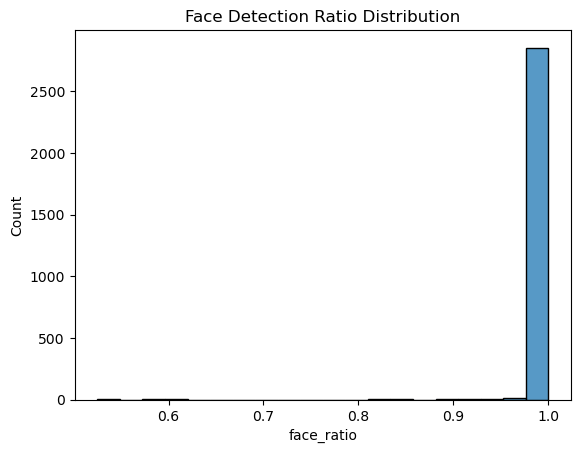

In [89]:
sns.histplot(df['face_ratio'], bins=20)
plt.title("Face Detection Ratio Distribution")
plt.show()

### Face Detection Analysis
This shows good results, where nearly all the videos have perfect facial tracking. There are a few videos that seem like they might have some issues, but we could possibly fix this with a better facial tracking method. Something to keep in mind, but nothing to do about it for our data prep.

In [91]:
df.head()

,video_path,emotion,actor_id,emotion_label,num_frames,fps,duration,width,height,motion,face_ratio
0,.\datasets\RAVDESS\Actor_01\01-01-01-01-01-01-...,neutral,1,5,99,29,3.413793,1280,720,29.921787,1.0
1,.\datasets\RAVDESS\Actor_01\01-01-01-01-01-02-...,neutral,1,5,100,29,3.448276,1280,720,32.842289,1.0
2,.\datasets\RAVDESS\Actor_01\01-01-01-01-02-01-...,neutral,1,5,98,29,3.379310,1280,720,34.853970,1.0
3,.\datasets\RAVDESS\Actor_01\01-01-01-01-02-02-...,neutral,1,5,95,29,3.275862,1280,720,33.747328,1.0
4,.\datasets\RAVDESS\Actor_01\01-01-02-01-01-01-...,calm,1,1,106,29,3.655172,1280,720,32.746136,1.0


Pickled the data to prevent re-running of the time-intensive steps in this notebook.

In [92]:
df.to_pickle("data_prep_1.pkl")